In [1]:
import pandas as pd
import matplotlib.pyplot as plt

#matplotlib - for drawing graphs  AND Pandas for reading csv files  , working with table
# Load the dataset. 'utf-8-sig' fixes that weird ï»¿ glitch in the first column!
movies = pd.read_csv('movies_updated.csv', encoding='utf-8-sig')


In [15]:
#task 1 explore dataset
movies.head()


,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,"runtime,,"
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772.0,Warner Bros.,"146.0,"
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106.0,Columbia Pictures,"104.0,"
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067.0,Lucasfilm,"124.0,"
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539.0,Paramount Pictures,"88.0,"
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344.0,Orion Pictures,"98.0,"


In [17]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   name       4000 non-null   object 
 1   rating     3960 non-null   object 
 2   genre      4000 non-null   object 
 3   year       4000 non-null   int64  
 4   released   4000 non-null   object 
 5   score      4000 non-null   float64
 6   votes      4000 non-null   int64  
 7   director   4000 non-null   object 
 8   writer     3999 non-null   object 
 9   star       3999 non-null   object 
 10  country    4000 non-null   object 
 11  budget     4000 non-null   int64  
 12  gross      3831 non-null   float64
 13  company    3990 non-null   object 
 14  runtime,,  4000 non-null   object 
dtypes: float64(2), int64(3), object(10)
memory usage: 468.9+ KB


None

In [5]:

display(movies.describe())

,year,score,votes,budget,gross
count,4000.000000,4000.000000,4.000000e+03,4.000000e+03,3.831000e+03
mean,1991.191500,6.321950,5.449450e+04,1.542740e+07,4.172202e+07
std,5.934529,0.977101,1.427738e+05,2.248639e+07,9.259504e+07
min,1980.000000,2.200000,5.100000e+01,0.000000e+00,3.090000e+02
25%,1986.000000,5.700000,4.300000e+03,0.000000e+00,2.835743e+06
50%,1991.000000,6.400000,1.300000e+04,7.000000e+06,1.183822e+07
75%,1996.000000,7.000000,4.500000e+04,2.100000e+07,3.560495e+07
max,2001.000000,9.300000,2.400000e+06,2.000000e+08,2.201647e+09


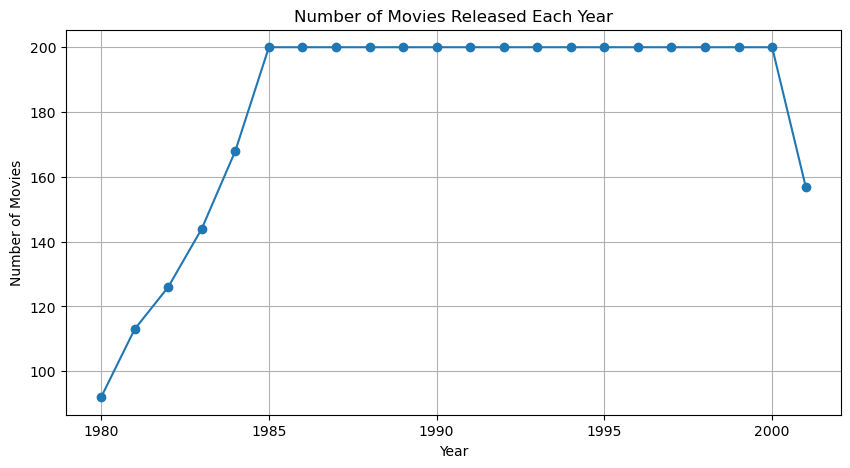

In [6]:
#task 2 number of movies released per year
# Count movies per year, sort by year, and plot a line chart
movies['year'].value_counts().sort_index().plot(kind='line', figsize=(10, 5), marker='o')

plt.title('Number of Movies Released Each Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.grid(True)
plt.show()

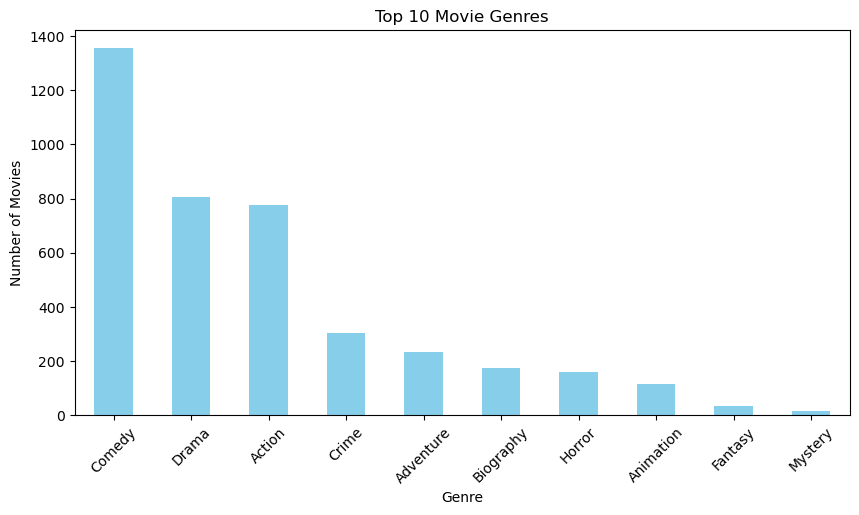

In [7]:
# Task 3 Get the top 10 genres and plot a vertical bar chart
movies['genre'].value_counts().head(10).plot(kind='bar', figsize=(10, 5), color='skyblue')

plt.title('Top 10 Movie Genres')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45) # Rotates the text so it's easy to read
plt.show()

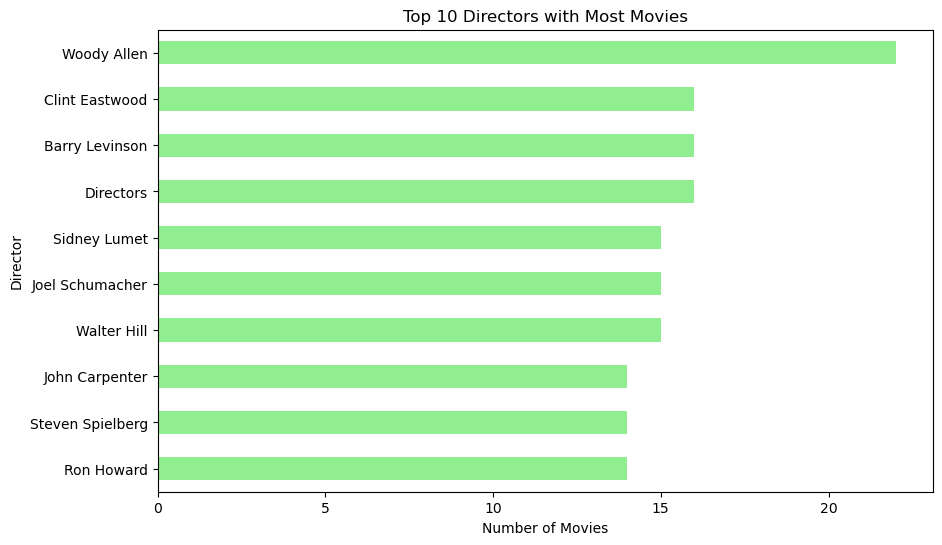

In [8]:
# task 4 top 10 directores to Get top 10 directors, sort ascending so the biggest is at the TOP of the graph
top_directors = movies['director'].value_counts().head(10).sort_values(ascending=True)
top_directors.plot(kind='barh', figsize=(10, 6), color='lightgreen')

plt.title('Top 10 Directors with Most Movies')
plt.xlabel('Number of Movies')
plt.ylabel('Director')
plt.show()

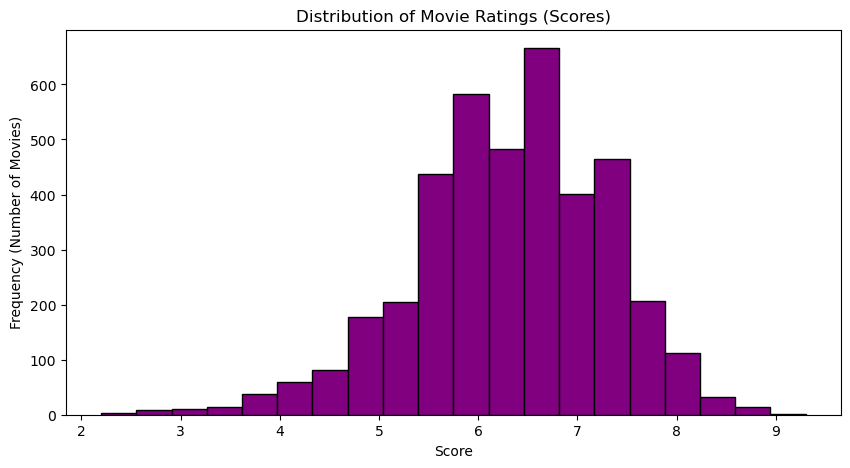

In [9]:
#task 5
movies['score'].plot(kind='hist', bins=20, figsize=(10, 5), color='purple', edgecolor='black')
#bins- dividing into 20 ranges
plt.title('Distribution of Movie Ratings (Scores)')
plt.xlabel('Score')
plt.ylabel('Frequency (Number of Movies)')
plt.show()

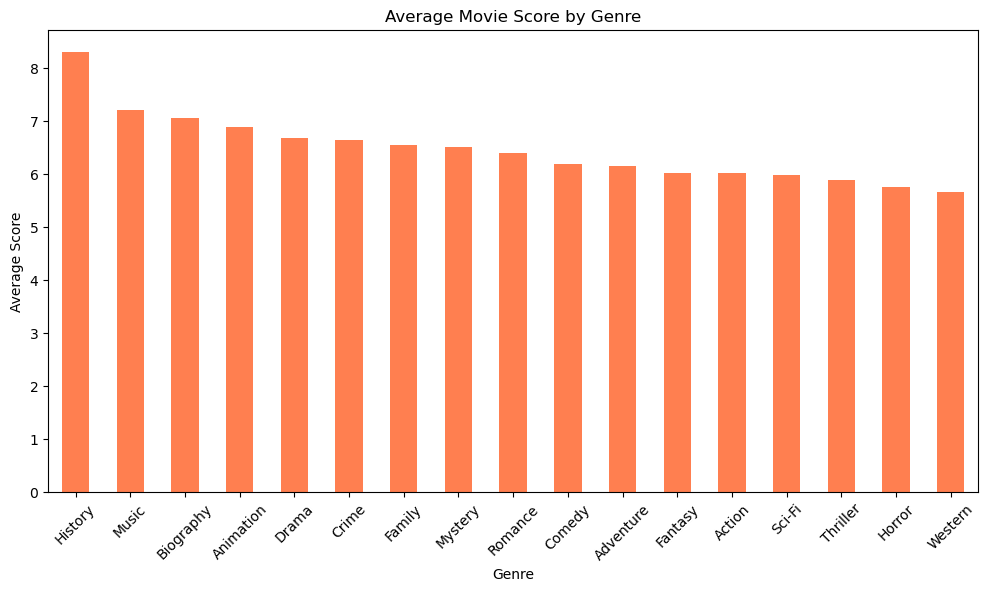

In [24]:
#average movie score by genre
# Calculate average score, sort descending, and plot
avg_score_by_genre = movies.groupby('genre')['score'].mean().sort_values(ascending=False)
avg_score_by_genre.plot(kind='bar', figsize=(12, 6), color='coral')

plt.title('Average Movie Score by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Score')
plt.xticks(rotation=45)
plt.show()

In [12]:
# This forces the very first column (index 0) to be named 'name', fixing the glitch!
movies.rename(columns={movies.columns[0]: 'name'}, inplace=True)

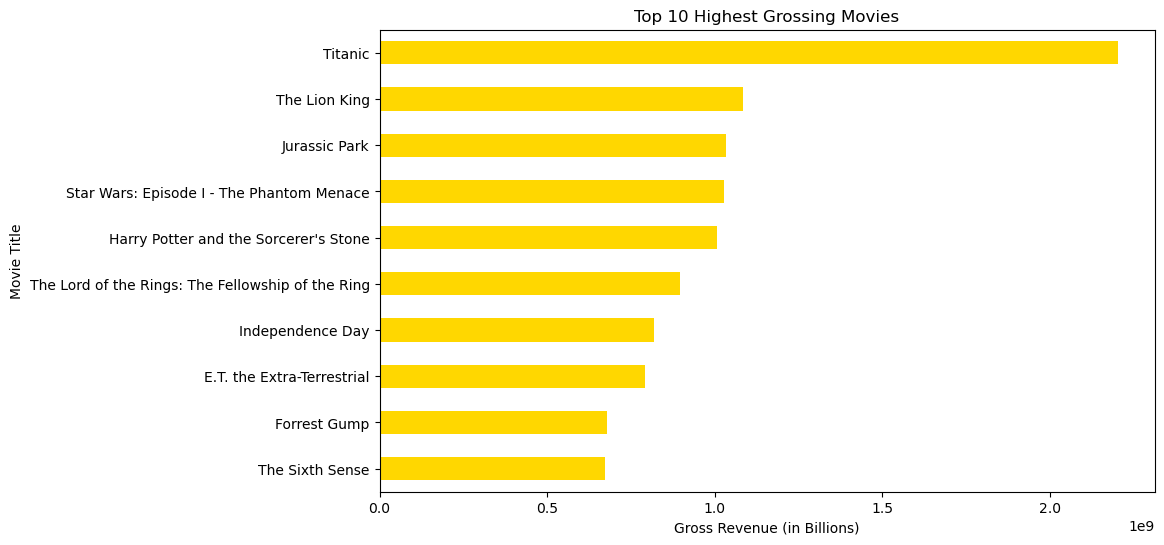

In [13]:
#Task 7: Top 10 Highest Grossing Movies
# Get the top 10 movies by gross revenue, sort ascending for the horizontal chart
top_grossing = movies.nlargest(10, 'gross').sort_values(by='gross', ascending=True)

top_grossing.plot(kind='barh', x='name', y='gross', figsize=(10, 6), color='gold', legend=False)

plt.title('Top 10 Highest Grossing Movies')
plt.xlabel('Gross Revenue (in Billions)')
plt.ylabel('Movie Title')
plt.show()